In [11]:
from pathlib import Path
from matplotlib import rc
import matplotlib.pyplot as plt

In [12]:
def set_rc_params(fontsize=None):
    '''
    Set figure parameters
    '''

    if fontsize is None:
        fontsize = 16
    else:
        fontsize = int(fontsize)

    rc('font', **{'family': 'serif'})
    rc('text', usetex=True)

    plt.rcParams.update({'axes.linewidth': 1.3})
    plt.rcParams.update({'xtick.labelsize': fontsize})
    plt.rcParams.update({'ytick.labelsize': fontsize})
    plt.rcParams.update({'xtick.major.size': 8})
    plt.rcParams.update({'xtick.major.width': 1.3})
    plt.rcParams.update({'xtick.minor.visible': True})
    plt.rcParams.update({'xtick.minor.width': 1.})
    plt.rcParams.update({'xtick.minor.size': 6})
    plt.rcParams.update({'xtick.direction': 'out'})
    plt.rcParams.update({'ytick.major.width': 1.3})
    plt.rcParams.update({'ytick.major.size': 8})
    plt.rcParams.update({'ytick.minor.visible': True})
    plt.rcParams.update({'ytick.minor.width': 1.})
    plt.rcParams.update({'ytick.minor.size': 6})
    plt.rcParams.update({'ytick.direction': 'out'})
    plt.rcParams.update({'axes.labelsize': fontsize})
    plt.rcParams.update({'axes.titlesize': fontsize})
    plt.rcParams.update({'legend.fontsize': int(fontsize-2)})
    plt.rcParams['text.usetex'] = True
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'


set_rc_params(15)

In [13]:
base_dir = Path("data/weatherbench")

models = [
    "egnn", "eman", "gcn", "gemcnn",
    "hermes", "mpnn", "transformer", "uni"
]

geopotential_500 = {}
temperature_860 = {}

for model in models:
    model_dir = base_dir / model

    geopotential_500[model] = xr.open_dataset(
        model_dir / "deterministic_geopotential_500.nc"
    )

    temperature_860[model] = xr.open_dataset(
        model_dir / "deterministic_temperature_850.nc"
    )


### Converting to Numpy things

In [14]:
import numpy as np

example_ds = geopotential_500[models[0]]

lead_time = example_ds["lead_time"].values
lead_time_days = lead_time / (24 * 3600 * 1e9)  

In [15]:
z500_mse = {}

for model in models:
    ds = geopotential_500[model]

    z500_mse[model] = np.sqrt((
        ds["geopotential"]
        .sel(metric="mse")
        .isel(level=0)
        .values   # → numpy array, shape (lead_time,)
    )) 

In [16]:
z500_acc = {}

for model in models:
    ds = geopotential_500[model]

    z500_acc[model] = (
        ds["geopotential"]
        .sel(metric="acc")
        .isel(level=0)
        .values
    )


In [17]:
import matplotlib.pyplot as plt
import numpy as np

set_rc_params(25)

egnn_rmse = np.load("data/weatherbench/egnn/geopotential_rmse_500.npy")
eman_rmse = np.load("data/weatherbench/eman/geopotential_rmse_500.npy")
gcn_rmse = np.load("data/weatherbench/gcn/geopotential_rmse_500.npy")
gem_rmse = np.load("data/weatherbench/gemcnn/geopotential_rmse_500.npy")
hermes_rmse = np.load("data/weatherbench/hermes/geopotential_rmse_500.npy")
mpnn_rmse = np.load("data/weatherbench/mpnn/geopotential_rmse_500.npy")
transformer_rmse = np.load("data/weatherbench/transformer/geopotential_rmse_500.npy")
uni_rmse = np.load("data/weatherbench/uni/geopotential_rmse_500.npy")

egnn_acc = np.load("data/weatherbench/egnn/geopotential_acc_500.npy")
eman_acc = np.load("data/weatherbench/eman/geopotential_acc_500.npy")
gcn_acc = np.load("data/weatherbench/gcn/geopotential_acc_500.npy")
gem_acc = np.load("data/weatherbench/gemcnn/geopotential_acc_500.npy")
hermes_acc = np.load("data/weatherbench/hermes/geopotential_acc_500.npy")
mpnn_acc = np.load("data/weatherbench/mpnn/geopotential_acc_500.npy")
transformer_acc = np.load("data/weatherbench/transformer/geopotential_acc_500.npy")
uni_acc = np.load("data/weatherbench/uni/geopotential_acc_500.npy")

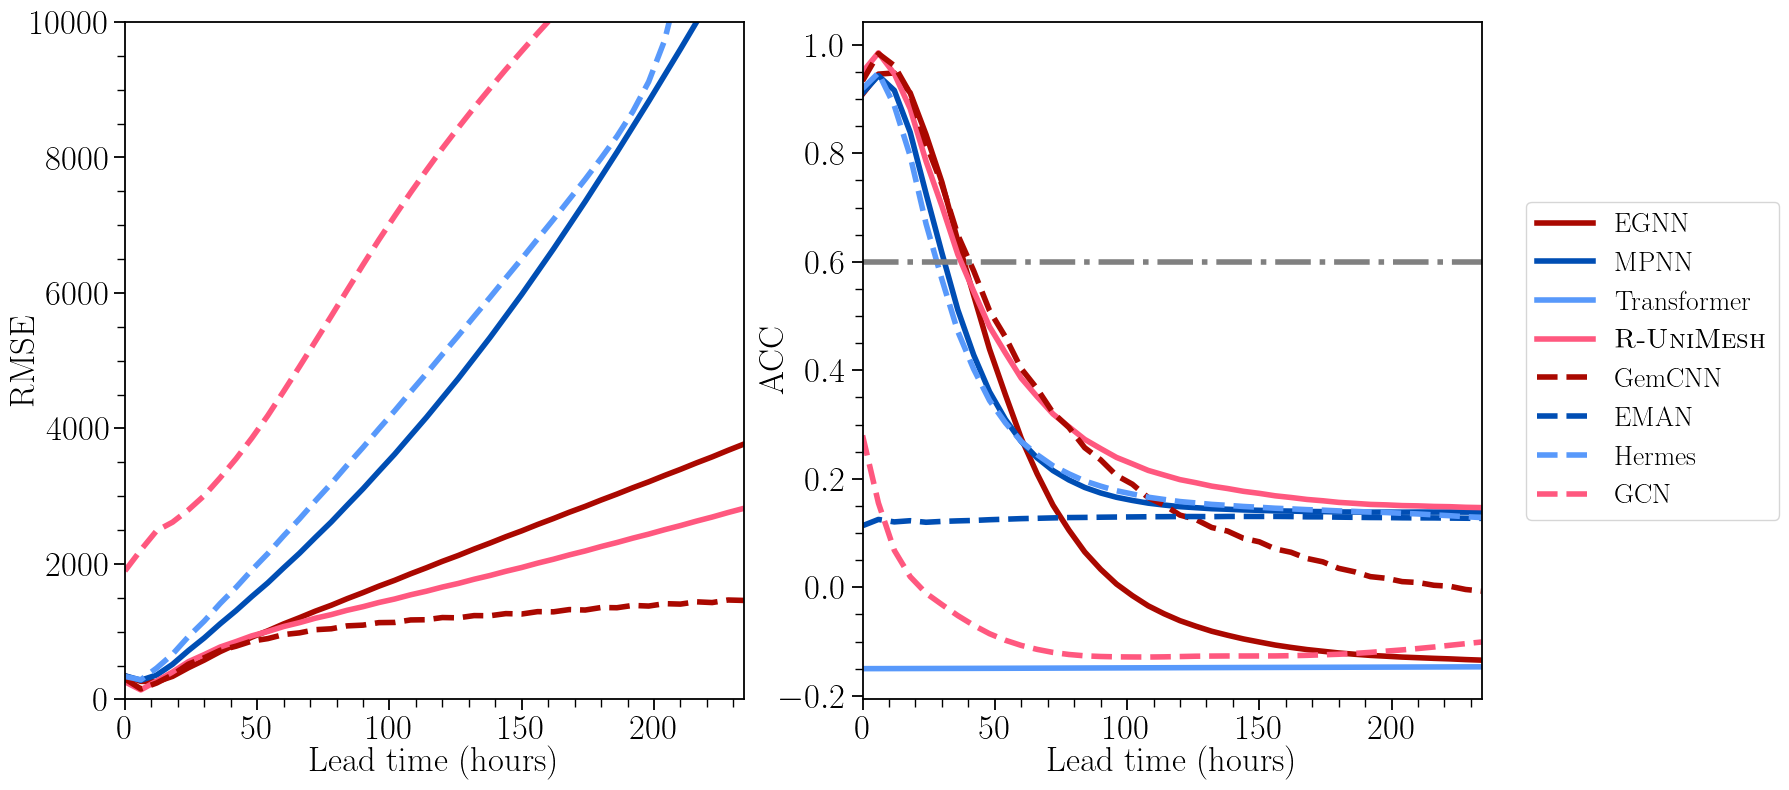

In [18]:
models = ["EGNN", "MPNN", "Transformer", r'$\textsc{R-UniMesh}$',
          "GemCNN", "EMAN", "Hermes", "GCN"]

rmse_arrays = [egnn_rmse, mpnn_rmse, transformer_rmse, uni_rmse,
               gem_rmse, eman_rmse, hermes_rmse, gcn_rmse]

acc_arrays = [egnn_acc, mpnn_acc, transformer_acc, uni_acc,
              gem_acc, eman_acc, hermes_acc, gcn_acc]

colors = [
    "#aa0800",
    "#004eb4",
    "#5899fb",
    "#ff587f",
]
linestyles = ["-", "--"]

model_styles = {}
for i, model in enumerate(models):
    color = colors[i % 4]
    linestyle = linestyles[i // 4]
    model_styles[model] = {"color": color, "linestyle": linestyle}

timesteps = np.arange(len(egnn_rmse))
hours = timesteps * 6 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# RMSE subplot
for model, rmse_array in zip(models, rmse_arrays):
    style = model_styles[model]
    ax1.plot(hours, rmse_array, color=style["color"],
             linestyle=style["linestyle"], lw=4, label=model)
ax1.set_xlabel("Lead time (hours)", labelpad=-0.5)
ax1.set_ylabel("RMSE", labelpad=-8)
ax1.set_ylim(0, 10000)
ax1.set_xlim(0, 234)

# ACC subplot
for model, acc_array in zip(models, acc_arrays):
    style = model_styles[model]
    ax2.plot(hours, acc_array, color=style["color"],
             linestyle=style["linestyle"], lw=4, label=model)
ax2.set_xlabel("Lead time (hours)", labelpad=-0.5)
ax2.set_ylabel("ACC", labelpad=-8)
ax2.axhline(y=0.6, color='gray', linestyle='-.', lw=4)
ax2.legend(fontsize=20, loc='center left', bbox_to_anchor=(1.05, 0.5))
ax2.set_xlim(0, 234)

plt.tight_layout()
plt.savefig("geopotential_metrics_horizontal.png", dpi=300)

In [19]:
import matplotlib.pyplot as plt
import numpy as np

set_rc_params(25)

# RMSE arrays
egnn_rmse = np.load("data/weatherbench/egnn/temperature_rmse_850.npy")
eman_rmse = np.load("data/weatherbench/eman/temperature_rmse_850.npy")
gcn_rmse = np.load("data/weatherbench/gcn/temperature_rmse_850.npy")
gem_rmse = np.load("data/weatherbench/gemcnn/temperature_rmse_850.npy")
hermes_rmse = np.load("data/weatherbench/hermes/temperature_rmse_850.npy")
mpnn_rmse = np.load("data/weatherbench/mpnn/temperature_rmse_850.npy")
transformer_rmse = np.load("data/weatherbench/transformer/temperature_rmse_850.npy")
uni_rmse = np.load("data/weatherbench/uni/temperature_rmse_850.npy")

# Accuracy arrays
egnn_acc = np.load("data/weatherbench/egnn/temperature_acc_850.npy")
eman_acc = np.load("data/weatherbench/eman/temperature_acc_850.npy")
gcn_acc = np.load("data/weatherbench/gcn/temperature_acc_850.npy")
gem_acc = np.load("data/weatherbench/gemcnn/temperature_acc_850.npy")
hermes_acc = np.load("data/weatherbench/hermes/temperature_acc_850.npy")
mpnn_acc = np.load("data/weatherbench/mpnn/temperature_acc_850.npy")
transformer_acc = np.load("data/weatherbench/transformer/temperature_acc_850.npy")
uni_acc = np.load("data/weatherbench/uni/temperature_acc_850.npy")


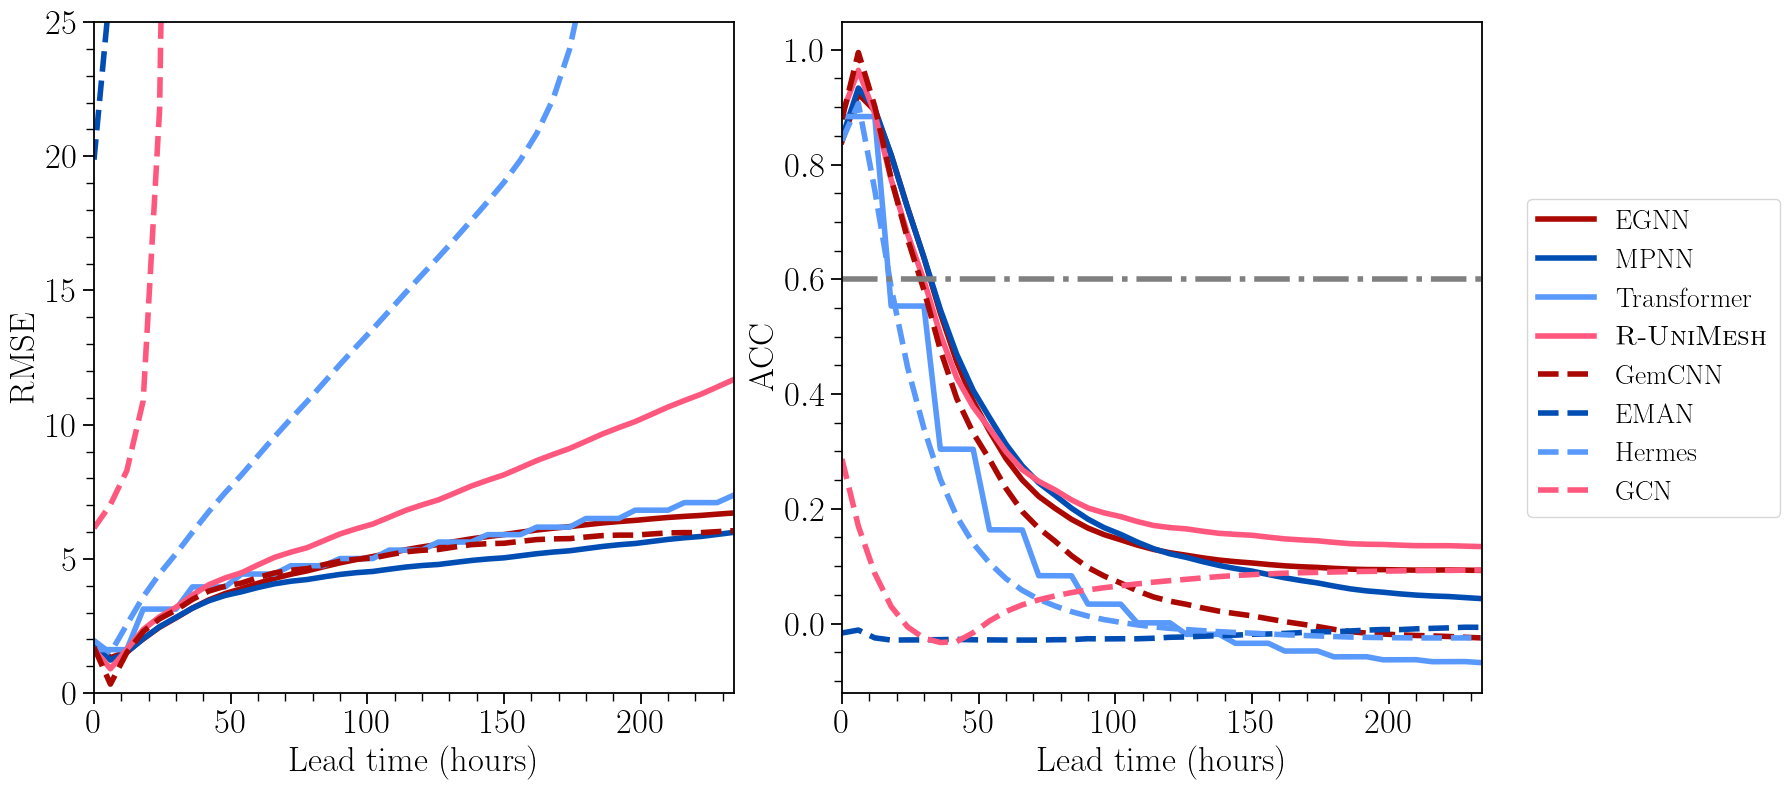

In [20]:
models = ["EGNN", "MPNN", "Transformer", r'$\textsc{R-UniMesh}$',
          "GemCNN", "EMAN", "Hermes", "GCN"]

rmse_arrays = [egnn_rmse, mpnn_rmse, transformer_rmse, uni_rmse,
               gem_rmse, eman_rmse, hermes_rmse, gcn_rmse]

acc_arrays = [egnn_acc, mpnn_acc, transformer_acc, uni_acc,
              gem_acc, eman_acc, hermes_acc, gcn_acc]

colors = [
    "#aa0800",
    "#004eb4",
    "#5899fb",
    "#ff587f",
]
linestyles = ["-", "--"]

model_styles = {}
for i, model in enumerate(models):
    color = colors[i % 4]
    linestyle = linestyles[i // 4]
    model_styles[model] = {"color": color, "linestyle": linestyle}

timesteps = np.arange(len(egnn_rmse))
hours = timesteps * 6 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# RMSE subplot
for model, rmse_array in zip(models, rmse_arrays):
    style = model_styles[model]
    ax1.plot(hours, rmse_array, color=style["color"],
             linestyle=style["linestyle"], lw=4, label=model)
ax1.set_xlabel("Lead time (hours)", labelpad=4)
ax1.set_ylabel("RMSE", labelpad=4)
ax1.set_ylim(0, 25)
ax1.set_xlim(0, 234)

# ACC subplot
for model, acc_array in zip(models, acc_arrays):
    style = model_styles[model]
    ax2.plot(hours, acc_array, color=style["color"],
             linestyle=style["linestyle"], lw=4, label=model)
ax2.set_xlabel("Lead time (hours)", labelpad=4)
ax2.set_ylabel("ACC", labelpad=4)
ax2.axhline(y=0.6, color='gray', linestyle='-.', lw=4)
ax2.legend(fontsize=20, loc='center left', bbox_to_anchor=(1.05, 0.5))
ax2.set_xlim(0, 234)

plt.tight_layout()
plt.savefig("temperature_metrics_horizontal.png", dpi=300)